In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/feature_extracted_data.csv")

df = df.drop(columns="Unnamed: 0")

df["activity"] = df["activity"].astype("category")
df["device"] = df["device"].astype("category")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 163925 entries, 0 to 163924
Data columns (total 56 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   device                   163925 non-null  category
 1   activity                 163925 non-null  category
 2   x_accel_mean             163925 non-null  float64 
 3   x_accel_std              163925 non-null  float64 
 4   x_accel_p25              163925 non-null  float64 
 5   x_accel_p75              163925 non-null  float64 
 6   x_accel_kurt             163925 non-null  float64 
 7   x_accel_autocorr         163925 non-null  float64 
 8   x_accel_rms              163925 non-null  float64 
 9   x_accel_dom_freq         163925 non-null  float64 
 10  x_accel_spectral_energy  163925 non-null  float64 
 11  y_accel_mean             163925 non-null  float64 
 12  y_accel_std              163925 non-null  float64 
 13  y_accel_p25              163925 non-null  float64 
 14 

In [3]:
df_phone = df[df["device"] == "phone"]
df_watch = df[df["device"] == "watch"]

df_phone = df_phone.drop(columns="device")
df_watch = df_watch.drop(columns="device")

In [4]:
df_phone

,activity,x_accel_mean,x_accel_std,x_accel_p25,x_accel_p75,x_accel_kurt,x_accel_autocorr,x_accel_rms,x_accel_dom_freq,x_accel_spectral_energy,...,y_gyro_spectral_energy,z_gyro_mean,z_gyro_std,z_gyro_p25,z_gyro_p75,z_gyro_kurt,z_gyro_autocorr,z_gyro_rms,z_gyro_dom_freq,z_gyro_spectral_energy
0,A,0.870997,2.857928,-1.350037,3.762543,-1.399069,-0.120179,2.945994,9.696970,4312.572588,...,1163.991032,-0.220454,0.660326,-0.737976,0.265854,-1.244075,0.851028,0.686598,1.212121,230.224043
1,A,0.735412,2.344767,-1.059269,2.166672,-0.297999,0.045216,2.429262,3.500000,4459.233822,...,1058.900251,-0.108883,0.633125,-0.571301,0.398396,-0.635107,0.597237,0.634572,1.000000,314.260730
2,A,0.720333,2.820879,-1.549858,2.771217,-0.428853,-0.238528,2.876144,9.743590,5896.401919,...,1132.695745,-0.042759,0.574698,-0.489609,0.361465,-0.625713,0.525619,0.568891,1.025641,244.735549
3,A,0.528281,2.024962,-1.146843,1.636425,-0.523692,0.171384,2.068100,4.000000,3237.865968,...,1171.034601,-0.035543,0.523660,-0.347092,0.364979,-0.307843,0.741960,0.518293,1.000000,214.191224
4,A,0.566024,3.383486,-0.857811,2.496716,1.214016,-0.542687,3.388534,9.000000,9962.823664,...,1388.430325,-0.070066,0.580034,-0.479481,0.352291,-0.607477,0.803165,0.577007,1.000000,265.059690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81969,S,-0.747637,0.431198,-1.005908,-0.459844,-0.193711,0.743613,0.860871,0.408163,218.655285,...,20.770264,-0.021044,0.211308,-0.191748,0.111853,-0.647037,0.921459,0.210196,0.816327,52.509483
81970,S,-0.815792,0.913786,-1.469345,-0.144300,-0.198464,0.937404,1.218122,0.400000,1023.017799,...,228.321366,0.066707,0.242605,-0.043410,0.157659,3.057164,0.868962,0.249258,1.200000,72.111454
81971,S,-1.913285,0.708221,-2.091451,-1.728007,18.466508,-0.237427,2.037696,2.400000,641.164231,...,353.357362,-0.014083,0.269127,-0.127832,0.069509,3.250627,0.640775,0.266794,0.800000,88.728358
81972,S,-1.697776,0.320425,-1.918411,-1.556763,-0.301505,0.523213,1.727142,2.857143,120.742437,...,74.646412,0.015827,0.099273,-0.043676,0.075634,-0.200209,0.814610,0.099522,1.632653,11.589729


In [5]:
df_phone.skew(numeric_only=True)

x_accel_mean               -0.095096
x_accel_std                 2.861490
x_accel_p25                -0.027234
x_accel_p75                -0.079942
x_accel_kurt                4.220236
x_accel_autocorr           -0.637964
x_accel_rms                 0.477586
x_accel_dom_freq            1.439572
x_accel_spectral_energy     9.631266
y_accel_mean                0.434019
y_accel_std                 2.578808
y_accel_p25                 0.126603
y_accel_p75                 0.585957
y_accel_kurt                4.179462
y_accel_autocorr           -0.590002
y_accel_rms                -0.011950
y_accel_dom_freq            1.321240
y_accel_spectral_energy     7.472207
z_accel_mean                0.014886
z_accel_std                 2.287900
z_accel_p25                 0.229228
z_accel_p75                -0.207052
z_accel_kurt                4.527407
z_accel_autocorr           -0.398995
z_accel_rms                 0.378893
z_accel_dom_freq            1.380326
z_accel_spectral_energy     6.098010
x

In [20]:
X_phone = df_phone.drop(columns="activity")
y_phone = df_phone["activity"]

X_watch = df_watch.drop(columns="activity")
y_watch = df_watch["activity"]

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_phone = le.fit_transform(y_phone)
y_watch = le.fit_transform(y_watch)

In [22]:
from sklearn.model_selection import train_test_split

X_train_phone, X_test_phone, y_train_phone, y_test_phone = train_test_split(
    X_phone, y_phone, test_size=0.2, random_state=42
)

X_train_watch, X_test_watch, y_train_watch, y_test_watch = train_test_split(
    X_watch, y_watch, test_size=0.2, random_state=42
)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score


def objective(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    max_depth = trial.suggest_int("max_depth", 5, 50)

    min_samples_split = trial.suggest_int("min_samples_split", 2, 5)

    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    criterion = trial.suggest_categorical("criterion", ["entropy", "gini"])

    max_features = trial.suggest_categorical(
        "max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]
    )

    max_samples = trial.suggest_categorical("max_samples", [0.9, 1])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features,
        max_samples=max_samples,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )

    score = cross_val_score(
        model,
        X_train_phone,
        y_train_phone,
        cv=3,
        scoring=make_scorer(f1_score, average="macro"),
        n_jobs=-1,
    ).mean()

    return score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
)


study.optimize(objective, n_trials=50)

[I 2026-07-31 22:19:14,516] A new study created in memory with name: no-name-fb591879-e10c-49df-8eab-d77f31d0ac32
[I 2026-07-31 22:19:43,385] Trial 0 finished with value: 0.8390356596974584 and parameters: {'n_estimators': 250, 'max_depth': 48, 'min_samples_split': 4, 'min_samples_leaf': 3, 'criterion': 'entropy', 'max_features': 'log2', 'max_samples': 0.9}. Best is trial 0 with value: 0.8390356596974584.
[I 2026-07-31 22:19:44,985] Trial 1 finished with value: 0.005921990743445556 and parameters: {'n_estimators': 185, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 2, 'criterion': 'entropy', 'max_features': 'log2', 'max_samples': 1}. Best is trial 0 with value: 0.8390356596974584.
[I 2026-07-31 22:19:46,569] Trial 2 finished with value: 0.005921990743445556 and parameters: {'n_estimators': 180, 'max_depth': 28, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'entropy', 'max_features': 0.3, 'max_samples': 1}. Best is trial 0 with value: 0.8390356596974584.
[I 2

In [ ]:
model = RandomForestClassifier(
    n_estimators=450,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="entropy",
    n_jobs=-1,
)

score = cross_val_score(
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    scoring=make_scorer(f1_score, average="macro"),
    n_jobs=-1,
).mean()

score

np.float64(0.8633970631136618)

In [42]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dc = DummyClassifier(strategy="most_frequent", random_state=42)

dc.fit(X_train_phone, y_train_phone)

y_pred_dummy = dc.predict(X_test_phone)

# 4. Calculate the F1-score (weighted for multi-class)
f1_dummy = f1_score(y_test_phone, y_pred_dummy, average="weighted")

print(f"Dummy Classifier F1-score (weighted): {f1_dummy:.4f}")

Dummy Classifier F1-score (weighted): 0.0053


In [43]:
from sklearn.model_selection import cross_val_predict

y_preds_phone = cross_val_predict(
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    n_jobs=-1,
)

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3724
           1       0.96      0.97      0.97      3554
           2       0.85      0.90      0.87      3642
           3       0.91      0.88      0.90      3741
           4       0.87      0.88      0.87      3700
           5       0.94      0.91      0.93      3519
           6       0.90      0.90      0.90      3692
           7       0.88      0.83      0.86      3661
           8       0.86      0.82      0.84      3502
           9       0.87      0.85      0.86      3593
          10       0.89      0.83      0.86      3689
          11       0.89      0.81      0.85      3580
          12       0.70      0.79      0.74      3762
          13       0.72      0.72      0.72      3599
          14       0.81      0.78      0.80      3631
          15       0.95      0.93      0.94      3676
          16       0.90      0.91      0.91      3679
          17       0.72    

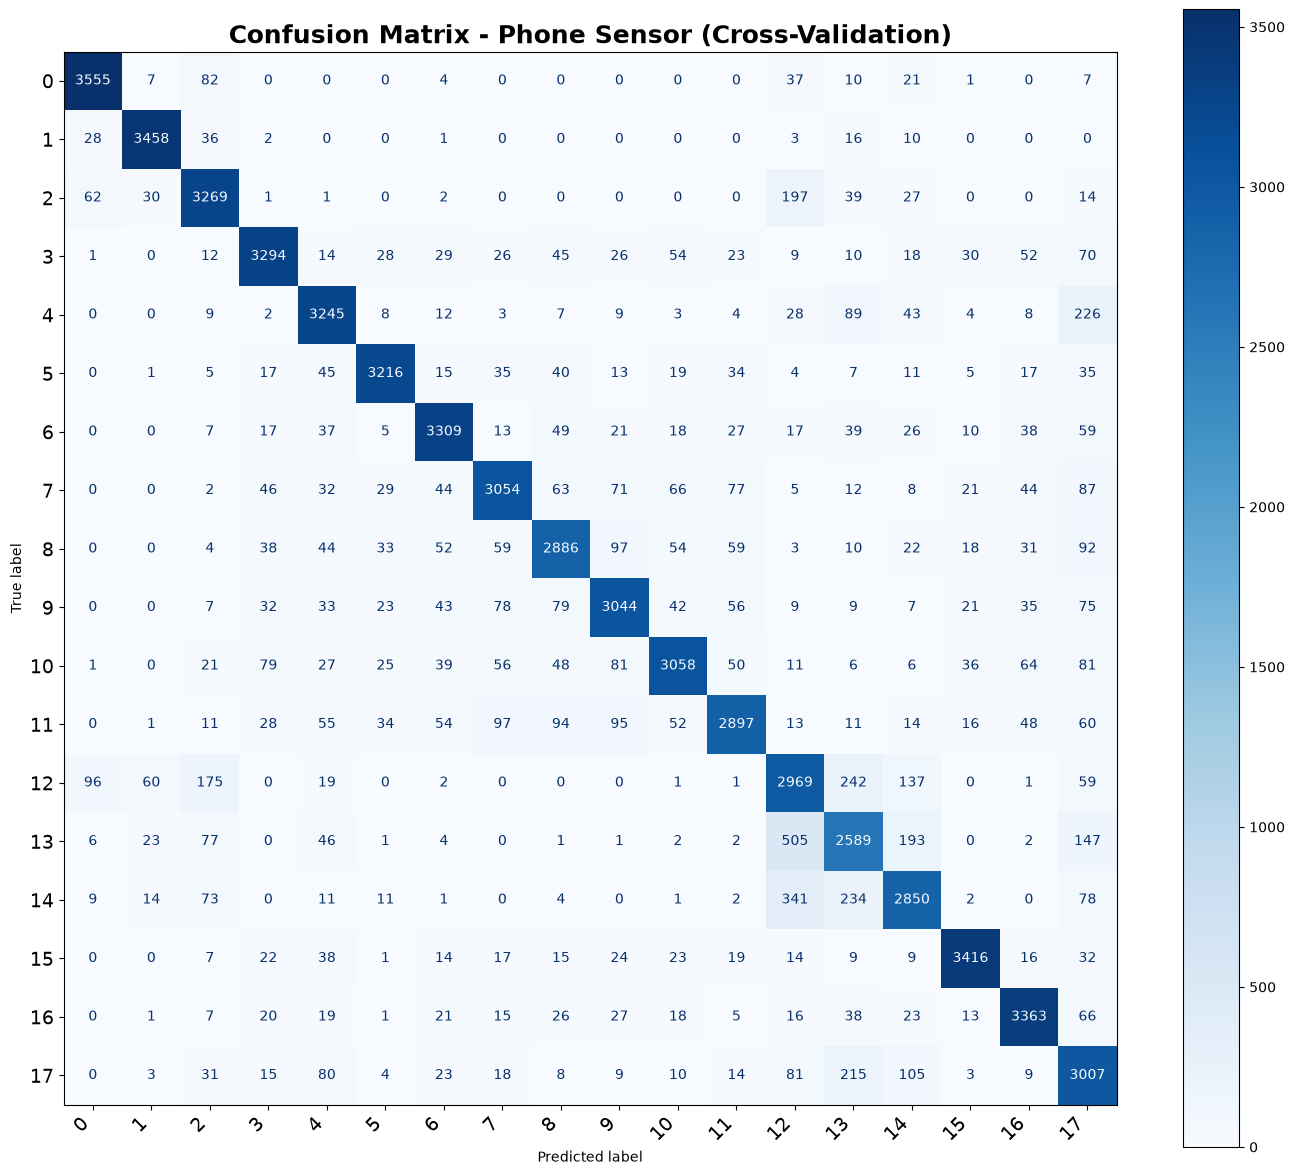

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print(classification_report(y_train_phone, y_preds_phone))


cm = confusion_matrix(y_train_phone, y_preds_phone)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using the display class
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", values_format="d")

disp.ax_.set_xticklabels(
    disp.ax_.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=14,
)

disp.ax_.set_yticklabels(disp.ax_.get_yticklabels(), fontsize=14)

disp.ax_.set_title(
    "Confusion Matrix - Phone Sensor (Cross-Validation)", fontsize=18, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
y_train_probs = cross_val_predict(
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    method="predict_proba",
    n_jobs=-1,
)

In [57]:
ACTIVITIES = {
    "A": "Walking",
    "B": "Jogging",
    "C": "Stairs",
    "D": "Sitting",
    "E": "Standing",
    "F": "Typing",
    "G": "Brushing Teeth",
    "H": "Eating Soup",
    "I": "Eating Chips",
    "J": "Eating Pasta",
    "K": "Drinking from Cup",
    "L": "Eating Sandwich",
    "M": "Kicking (Soccer Ball)",
    "O": "Playing Catch w/Tennis Ball",
    "P": "Dribbling (Basketball)",
    "Q": "Writing",
    "R": "Clapping",
    "S": "Folding Clothes",
}

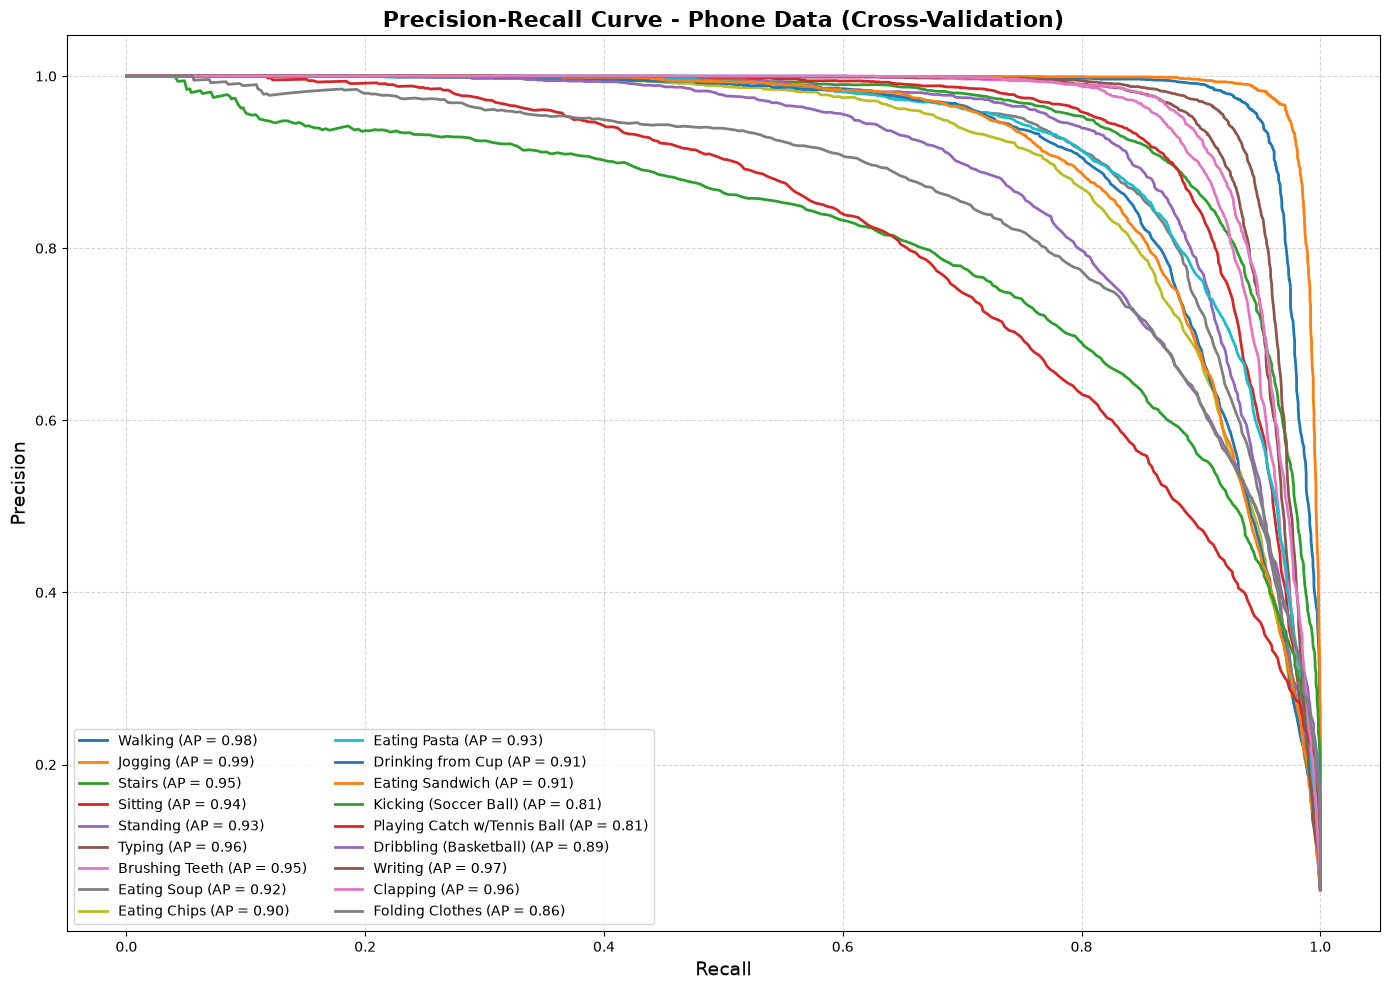

In [60]:
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y_train_phone)
y_train_bin = label_binarize(y_train_phone, classes=classes)
n_classes = len(classes)

numeric_to_name = {i: ACTIVITIES[le.inverse_transform([i])[0]] for i in classes}

plt.figure(figsize=(14, 10))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_train_bin[:, i], y_train_probs[:, i]  # type: ignore
    )
    ap_score = average_precision_score(y_train_bin[:, i], y_train_probs[:, i])  # type: ignore

    label_name = numeric_to_name[i]
    plt.plot(recall, precision, lw=2, label=f"{label_name} (AP = {ap_score:.2f})")

plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title(
    "Precision-Recall Curve - Phone Data (Cross-Validation)",
    fontsize=16,
    fontweight="bold",
)
plt.legend(
    loc="lower left", fontsize=10, ncol=2
)  # ncol=2 makes it a grid so it doesn't overlap
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

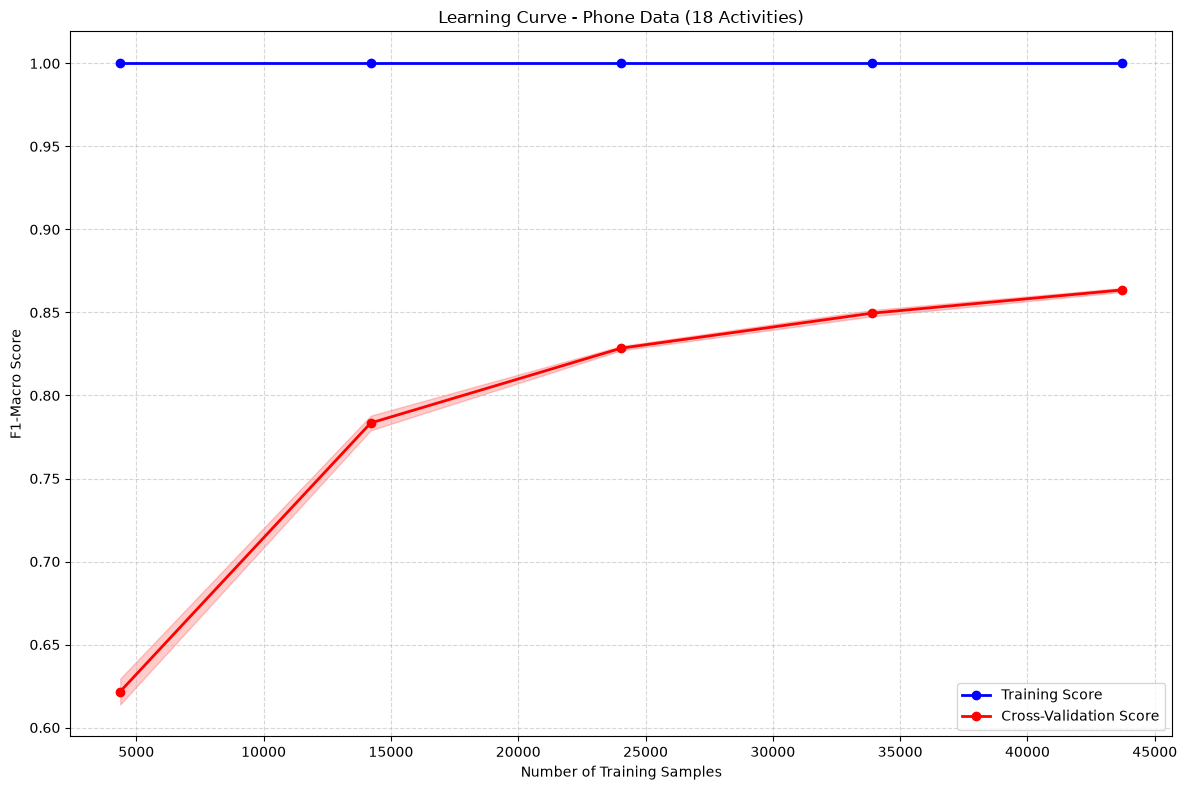

In [62]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(  # type: ignore
    model,
    X_train_phone,
    y_train_phone,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(12, 8))

plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training Score", lw=2)
plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue"
)

plt.plot(train_sizes, val_mean, "o-", color="red", label="Cross-Validation Score", lw=2)
plt.fill_between(
    train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="red"
)

plt.xlabel(
    "Number of Training Samples",
)
plt.ylabel(
    "F1-Macro Score",
)
plt.title(f"Learning Curve - Phone Data ({len(np.unique(y_train_phone))} Activities)")
plt.legend(
    loc="best",
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [63]:
model_watch = RandomForestClassifier(
    n_estimators=450,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="entropy",
    n_jobs=-1,
)

score = cross_val_score(
    model,
    X_train_watch,
    y_train_watch,
    cv=3,
    scoring=make_scorer(f1_score, average="macro"),
    n_jobs=-1,
).mean()

score

np.float64(0.8042928293082223)

In [66]:
from sklearn.model_selection import cross_val_predict

y_preds_watch = cross_val_predict(
    model,
    X_train_watch,
    y_train_watch,
    cv=3,
    n_jobs=-1,
)

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      3730
           1       0.97      0.96      0.96      3627
           2       0.81      0.68      0.74      3485
           3       0.84      0.77      0.81      3688
           4       0.89      0.83      0.86      3658
           5       0.87      0.92      0.89      3615
           6       0.94      0.94      0.94      3654
           7       0.68      0.77      0.72      3605
           8       0.62      0.57      0.59      3590
           9       0.65      0.70      0.68      3617
          10       0.73      0.75      0.74      3702
          11       0.64      0.47      0.54      3563
          12       0.77      0.79      0.78      3723
          13       0.81      0.82      0.82      3542
          14       0.95      0.91      0.93      3661
          15       0.89      0.94      0.91      3693
          16       0.97      0.97      0.97      3674
          17       0.64    

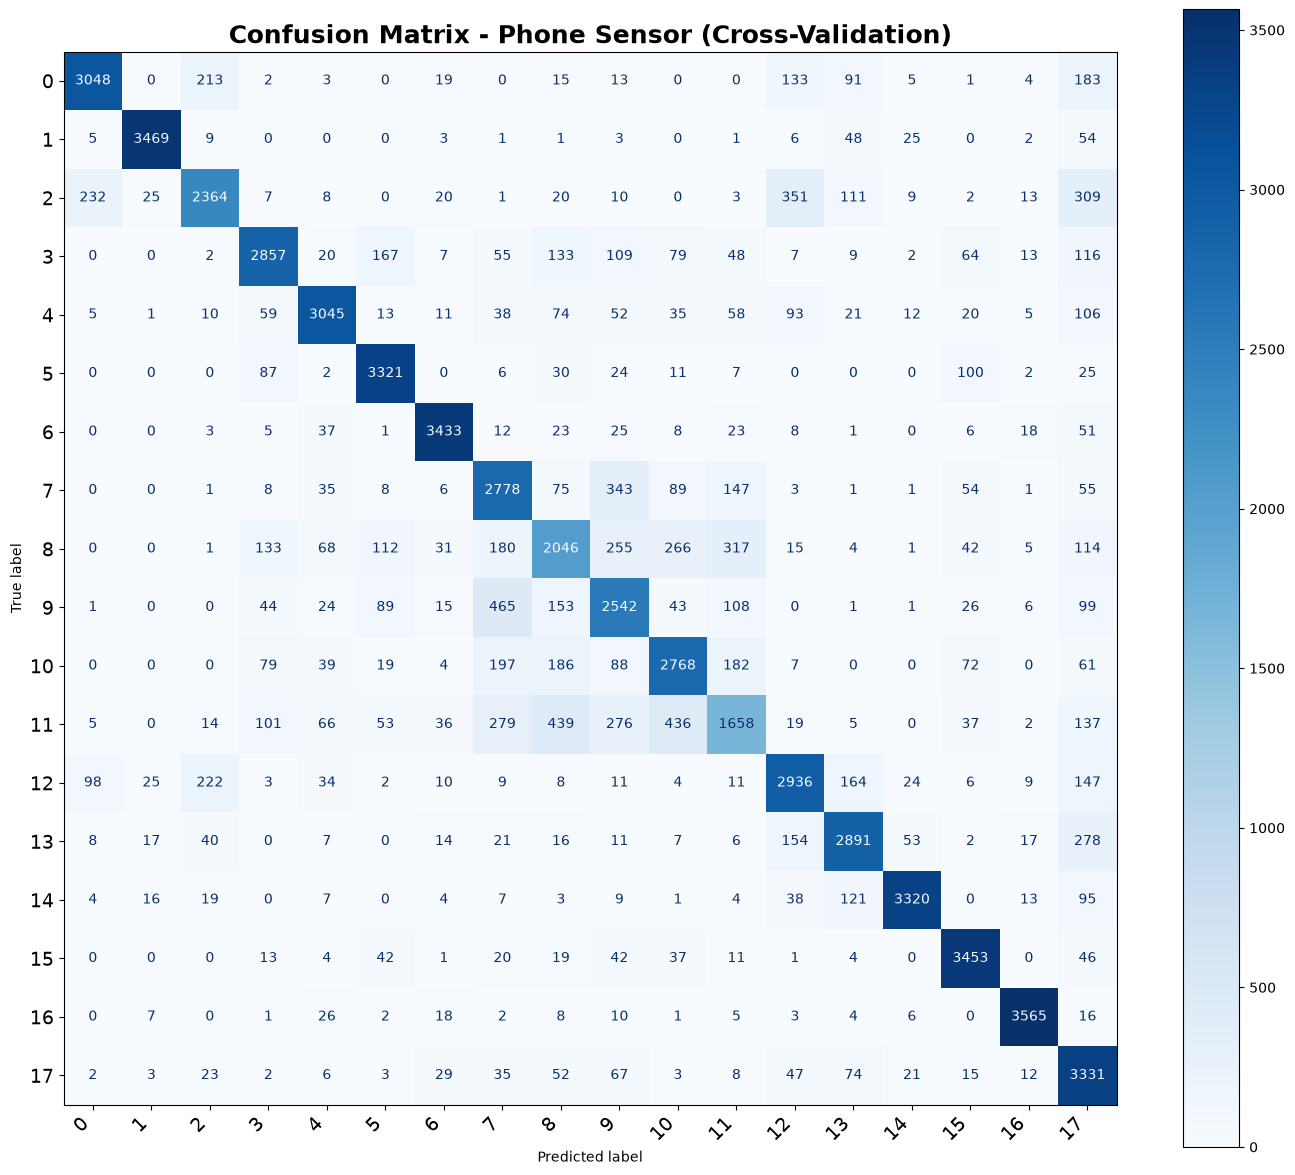

In [67]:
print(classification_report(y_train_watch, y_preds_watch))


cm = confusion_matrix(y_train_watch, y_preds_watch)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using the display class
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", values_format="d")

disp.ax_.set_xticklabels(
    disp.ax_.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=14,
)

disp.ax_.set_yticklabels(disp.ax_.get_yticklabels(), fontsize=14)

disp.ax_.set_title(
    "Confusion Matrix - Phone Sensor (Cross-Validation)", fontsize=18, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [68]:
y_train_probs = cross_val_predict(
    model,
    X_train_watch,
    y_train_watch,
    cv=3,
    method="predict_proba",
    n_jobs=-1,
)

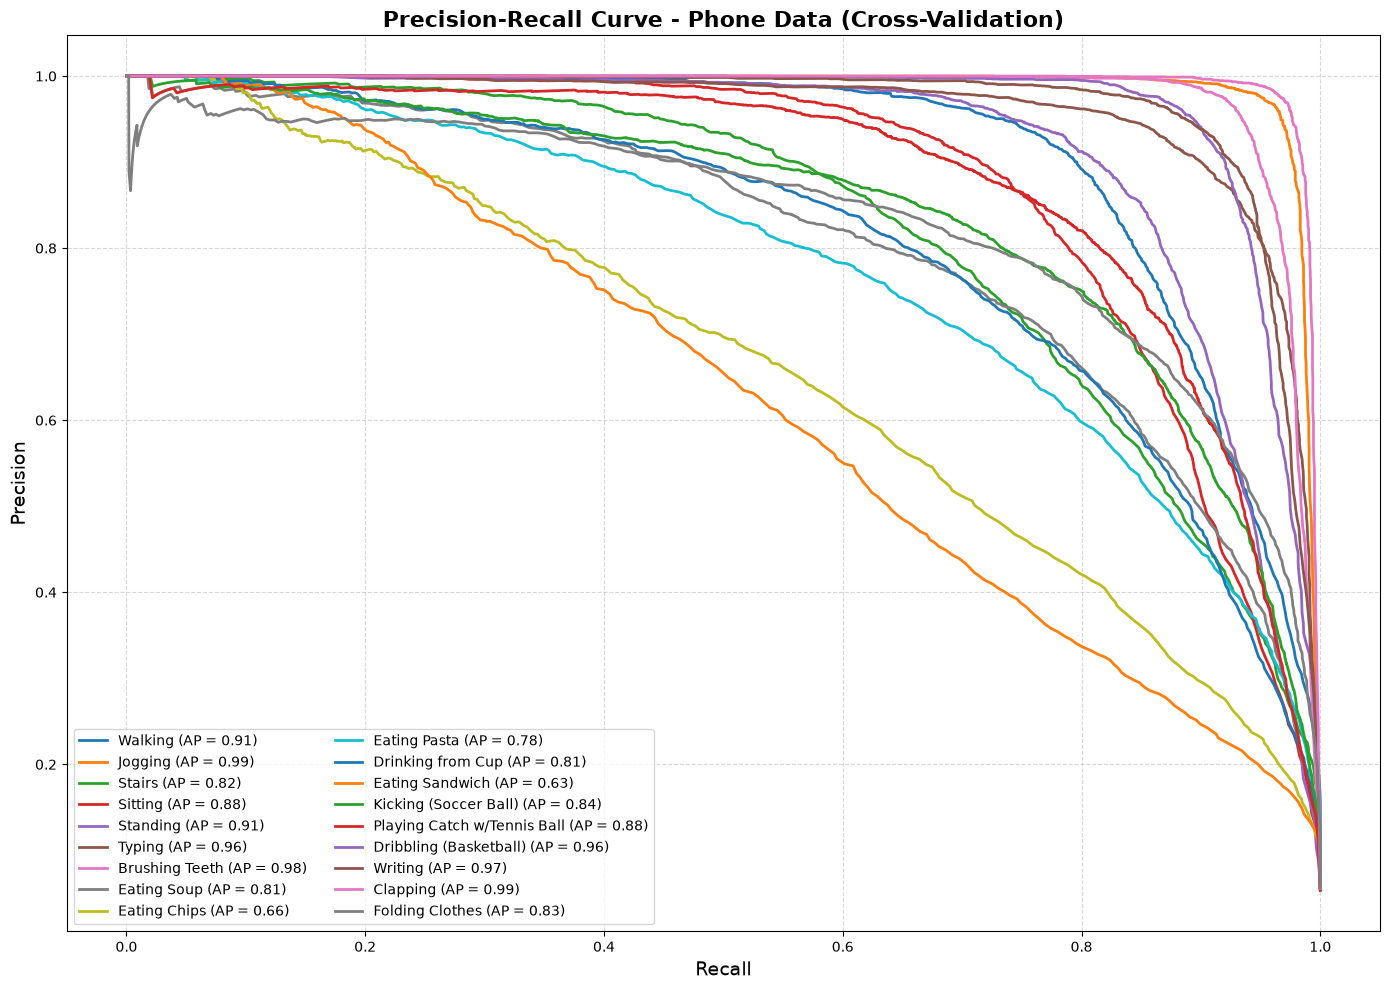

In [69]:
classes = np.unique(y_train_watch)
y_train_bin = label_binarize(y_train_watch, classes=classes)
n_classes = len(classes)

numeric_to_name = {i: ACTIVITIES[le.inverse_transform([i])[0]] for i in classes}

plt.figure(figsize=(14, 10))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_train_bin[:, i], y_train_probs[:, i]  # type: ignore
    )
    ap_score = average_precision_score(y_train_bin[:, i], y_train_probs[:, i])  # type: ignore

    label_name = numeric_to_name[i]
    plt.plot(recall, precision, lw=2, label=f"{label_name} (AP = {ap_score:.2f})")

plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title(
    "Precision-Recall Curve - Phone Data (Cross-Validation)",
    fontsize=16,
    fontweight="bold",
)
plt.legend(
    loc="lower left", fontsize=10, ncol=2
)  # ncol=2 makes it a grid so it doesn't overlap
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

def objective(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    max_depth = trial.suggest_int("max_depth", 5, 50)

    min_samples_split = trial.suggest_int("min_samples_split", 2, 5)

    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    criterion = trial.suggest_categorical("criterion", ["entropy", "gini"])

    max_features = trial.suggest_categorical(
        "max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]
    )

    max_samples = trial.suggest_categorical("max_samples", [0.9, 1])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features,
        max_samples=max_samples,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )

    score = cross_val_score(
        model,
        X_train_watch,
        y_train_watch,
        cv=3,
        scoring=make_scorer(f1_score, average="macro"),
        n_jobs=-1,
    ).mean()

    return score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
)


study.optimize(objective, n_trials=50)